In [11]:
import sys
import os
import torch
import pytorch_lightning as pl
import matplotlib.pyplot as plt
import pandas as pd
import shutil
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_lightning.loggers import CSVLogger


sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from src.torch_lightning.lightning_data_module import DroneDataModule
from src.torch_lightning.lightning_module import DroneClassifier

pl.seed_everything(42)

Seed set to 42


42

In [12]:
ROOT_DIR = "data"
BATCH_SIZE = 16
NUM_WORKERS = 0

SAMPLE_RATE = 16000
DURATION = 2.0
N_MELS = 128
N_FFT = 1024
HOP_LENGTH = 256

LEARNING_RATE = 1e-3
MAX_EPOCHS = 20

VARIANTS = ["original", "noisy", "noisy_kalman"]

RESULTS = []

In [13]:
if os.path.exists("logs"):
    shutil.rmtree("logs")
    print("Usunięto folder logs")

if os.path.exists("results"):
    shutil.rmtree("results")
    print("Usunięto folder results")

RESULTS = []
print("Zresetowano RESULTS")

Usunięto folder logs
Usunięto folder results
Zresetowano RESULTS


In [14]:
def run_experiment(dataset_type: str, variant: str):
    print("\n" + "=" * 80)
    print(f"START: dataset_type={dataset_type} | variant={variant}")
    print("=" * 80)

    dm = DroneDataModule(
        root_dir=ROOT_DIR,
        dataset_type=dataset_type,
        variant=variant,
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS,
        sample_rate=SAMPLE_RATE,
        duration=DURATION,
        n_mels=N_MELS,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        noise_std=0.01,
        kalman_q=1e-5,
        kalman_r=1e-3,
        seed=42,
    )

    dm.prepare_data()
    dm.setup()

    num_classes = len(dm.class_to_idx)

    model = DroneClassifier(
        num_classes=num_classes,
        n_mels=N_MELS,
        learning_rate=LEARNING_RATE,
    )

    experiment_name = f"{dataset_type}_{variant}"

    logger = CSVLogger(
        save_dir="logs",
        name="drone_mamba",
        version=experiment_name,
    )

    checkpoint_callback = ModelCheckpoint(
        monitor="val_acc",
        mode="max",
        save_top_k=1,
        filename=experiment_name + "-{epoch:02d}-{val_acc:.4f}",
    )

    early_stopping = EarlyStopping(
        monitor="val_acc",
        mode="max",
        patience=5,
    )

    trainer = pl.Trainer(
        max_epochs=MAX_EPOCHS,
        accelerator="auto",
        devices=1,
        logger=logger,
        callbacks=[checkpoint_callback, early_stopping],
        log_every_n_steps=10,
    )

    trainer.fit(model, datamodule=dm)
    test_results = trainer.test(model, datamodule=dm)

    result_row = {
        "dataset_type": dataset_type,
        "variant": variant,
        "num_classes": num_classes,
        "best_checkpoint": checkpoint_callback.best_model_path,
    }

    if len(test_results) > 0:
        for key, value in test_results[0].items():
            result_row[key] = value

    RESULTS.append(result_row)

    print(f"BEST CHECKPOINT: {checkpoint_callback.best_model_path}")
    print("=" * 80)

    return result_row

In [15]:
dm_original = DroneDataModule(root_dir=ROOT_DIR, dataset_type="binary", variant="original", batch_size=1)
dm_noisy = DroneDataModule(root_dir=ROOT_DIR, dataset_type="binary", variant="noisy", batch_size=1)
dm_kalman = DroneDataModule(root_dir=ROOT_DIR, dataset_type="binary", variant="noisy_kalman", batch_size=1)

dm_original.prepare_data(); dm_original.setup()
dm_noisy.prepare_data(); dm_noisy.setup()
dm_kalman.prepare_data(); dm_kalman.setup()

x_orig, y_orig = dm_original.train_dataset[0]
x_noisy, y_noisy = dm_noisy.train_dataset[0]
x_kalman, y_kalman = dm_kalman.train_dataset[0]

print("Label original:", y_orig.item())
print("Label noisy:", y_noisy.item())
print("Label kalman:", y_kalman.item())

print("Original mean/std:", x_orig.mean().item(), x_orig.std().item())
print("Noisy mean/std:", x_noisy.mean().item(), x_noisy.std().item())
print("Kalman mean/std:", x_kalman.mean().item(), x_kalman.std().item())

print("orig vs noisy equal:", bool((x_orig == x_noisy).all()))
print("orig vs kalman equal:", bool((x_orig == x_kalman).all()))
print("noisy vs kalman equal:", bool((x_noisy == x_kalman).all()))

Dataset root: data
Selected data dir: data\DroneAudioDataset-master\Binary_Drone_Audio
Dataset type: binary
Variant: original
Class to idx: {'unknown': 0, 'yes_drone': 1}
Train size: 8192
Val size: 1755
Test size: 1757
Dataset root: data
Selected data dir: data\DroneAudioDataset-master\Binary_Drone_Audio
Dataset type: binary
Variant: noisy
Class to idx: {'unknown': 0, 'yes_drone': 1}
Train size: 8192
Val size: 1755
Test size: 1757
Dataset root: data
Selected data dir: data\DroneAudioDataset-master\Binary_Drone_Audio
Dataset type: binary
Variant: noisy_kalman
Class to idx: {'unknown': 0, 'yes_drone': 1}
Train size: 8192
Val size: 1755
Test size: 1757
Label original: 0
Label noisy: 0
Label kalman: 0
Original mean/std: 0.0 0.0
Noisy mean/std: 0.6752897500991821 0.10434037446975708
Kalman mean/std: 0.4059399366378784 0.19277910888195038
orig vs noisy equal: False
orig vs kalman equal: False
noisy vs kalman equal: False


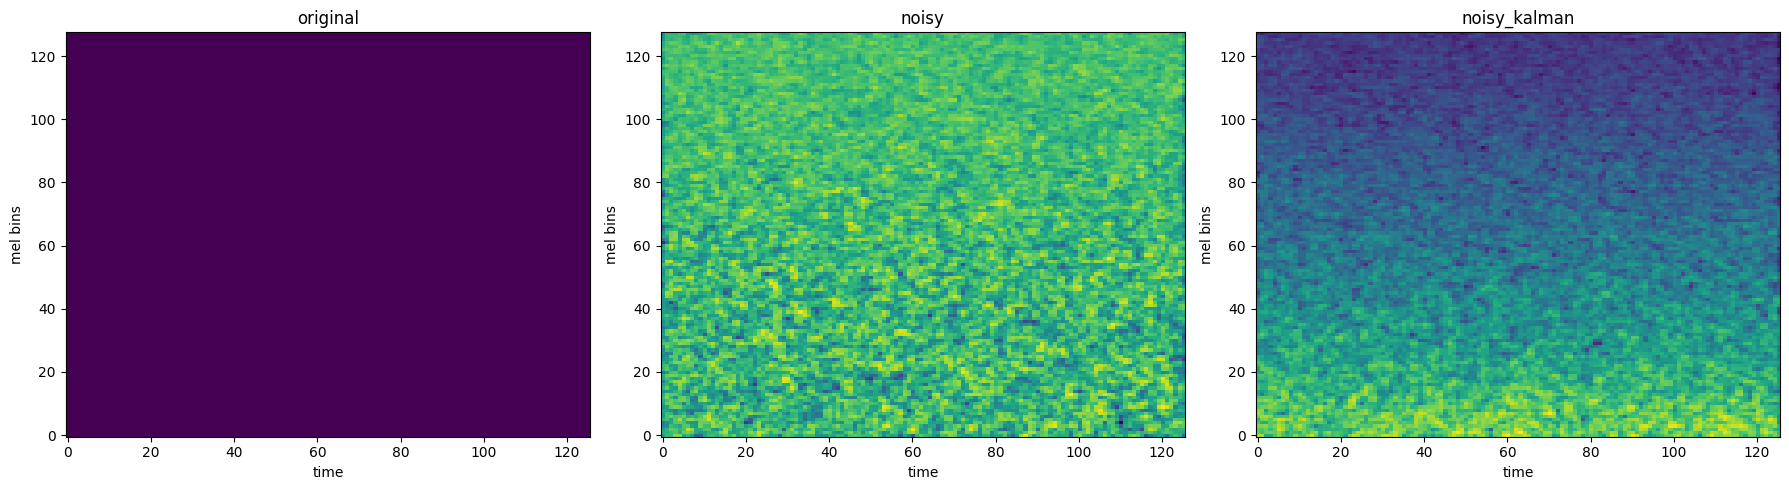

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(x_orig.squeeze(0).numpy(), aspect="auto", origin="lower")
axes[0].set_title("original")

axes[1].imshow(x_noisy.squeeze(0).numpy(), aspect="auto", origin="lower")
axes[1].set_title("noisy")

axes[2].imshow(x_kalman.squeeze(0).numpy(), aspect="auto", origin="lower")
axes[2].set_title("noisy_kalman")

for ax in axes:
    ax.set_xlabel("time")
    ax.set_ylabel("mel bins")

plt.tight_layout()
plt.show()

In [17]:
RESULTS = []
run_experiment(dataset_type="binary", variant="original")


START: dataset_type=binary | variant=original
Dataset root: data
Selected data dir: data\DroneAudioDataset-master\Binary_Drone_Audio
Dataset type: binary
Variant: original
Class to idx: {'unknown': 0, 'yes_drone': 1}
Train size: 8192
Val size: 1755
Test size: 1757


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type                      | Params | Mode 
------------------------------------------------------------------
0 | model       | DroneDetectorMamba        | 6.1 M  | train
1 | loss_fn     | CrossEntropyLoss          | 0      | train
2 | train_acc   | MulticlassAccuracy        | 0      | train
3 | val_acc     | MulticlassAccuracy        | 0      | train
4 | test_acc    | MulticlassAccuracy        | 0      | train
5 | test_f1     | MulticlassF1Score         | 0      | train
6 | conf_matrix | MulticlassConfusionMatrix | 0      | train
------------------------------------------------------------------
6.1 M     Trainable params
0         Non-trainable params
6.1 M     Total params
24.478    Total estimated model params size (MB)
46        Modules in train mode
0         Modules in eval mode


Dataset root: data
Selected data dir: data\DroneAudioDataset-master\Binary_Drone_Audio
Dataset type: binary
Variant: original
Class to idx: {'unknown': 0, 'yes_drone': 1}
Train size: 8192
Val size: 1755
Test size: 1757
Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\jango\Anaconda\envs\segm-env\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


c:\Users\jango\Anaconda\envs\segm-env\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


...

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 512/512 [01:13<00:00,  6.95it/s, v_num=inal, val_loss=0.0357, val_acc=0.989, train_loss=0.0512, train_acc=0.986]
Dataset root: data
Selected data dir: data\DroneAudioDataset-master\Binary_Drone_Audio
Dataset type: binary
Variant: original
Class to idx: {'unknown': 0, 'yes_drone': 1}
Train size: 8192
Val size: 1755
Test size: 1757


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\jango\Anaconda\envs\segm-env\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████| 110/110 [00:14<00:00,  7.55it/s]
Confusion Matrix:
tensor([[1540,   24],
        [   3,  190]], device='cuda:0')
Testing DataLoader 0: 100%|██████████| 110/110 [00:14<00:00,  7.54it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.9846329092979431
         test_f1            0.9624854326248169
        test_loss           0.03614521026611328
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
BEST CHECKPOINT: logs\drone_mamba\binary_original\checkpoints\binary_original-epoch=16-val_acc=0.9932.ckpt


{'dataset_type': 'binary',
 'variant': 'original',
 'num_classes': 2,
 'best_checkpoint': 'logs\\drone_mamba\\binary_original\\checkpoints\\binary_original-epoch=16-val_acc=0.9932.ckpt',
 'test_loss': 0.03614521026611328,
 'test_acc': 0.9846329092979431,
 'test_f1': 0.9624854326248169}

In [18]:
run_experiment(dataset_type="binary", variant="noisy")


START: dataset_type=binary | variant=noisy
Dataset root: data
Selected data dir: data\DroneAudioDataset-master\Binary_Drone_Audio
Dataset type: binary
Variant: noisy
Class to idx: {'unknown': 0, 'yes_drone': 1}
Train size: 8192
Val size: 1755
Test size: 1757


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


Dataset root: data
Selected data dir: data\DroneAudioDataset-master\Binary_Drone_Audio
Dataset type: binary
Variant: noisy
Class to idx: {'unknown': 0, 'yes_drone': 1}
Train size: 8192
Val size: 1755
Test size: 1757


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type                      | Params | Mode 
------------------------------------------------------------------
0 | model       | DroneDetectorMamba        | 6.1 M  | train
1 | loss_fn     | CrossEntropyLoss          | 0      | train
2 | train_acc   | MulticlassAccuracy        | 0      | train
3 | val_acc     | MulticlassAccuracy        | 0      | train
4 | test_acc    | MulticlassAccuracy        | 0      | train
5 | test_f1     | MulticlassF1Score         | 0      | train
6 | conf_matrix | MulticlassConfusionMatrix | 0      | train
------------------------------------------------------------------
6.1 M     Trainable params
0         Non-trainable params
6.1 M     Total params
24.478    Total estimated model params size (MB)
46        Modules in train mode
0         Modules in eval mode


Epoch 5: 100%|██████████| 512/512 [01:21<00:00,  6.26it/s, v_num=oisy, val_loss=0.261, val_acc=0.875, train_loss=0.324, train_acc=0.887]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



Dataset root: data
Selected data dir: data\DroneAudioDataset-master\Binary_Drone_Audio
Dataset type: binary
Variant: noisy
Class to idx: {'unknown': 0, 'yes_drone': 1}
Train size: 8192
Val size: 1755
Test size: 1757
Testing DataLoader 0: 100%|██████████| 110/110 [00:16<00:00,  6.78it/s]
Confusion Matrix:
tensor([[1564,    0],
        [ 193,    0]], device='cuda:0')
Testing DataLoader 0: 100%|██████████| 110/110 [00:16<00:00,  6.76it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.8901536464691162
         test_f1            0.47094249725341797
        test_loss           0.23327378928661346
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
BEST CHEC

{'dataset_type': 'binary',
 'variant': 'noisy',
 'num_classes': 2,
 'best_checkpoint': 'logs\\drone_mamba\\binary_noisy\\checkpoints\\binary_noisy-epoch=00-val_acc=0.8752.ckpt',
 'test_loss': 0.23327378928661346,
 'test_acc': 0.8901536464691162,
 'test_f1': 0.47094249725341797}

In [19]:
run_experiment(dataset_type="binary", variant="noisy_kalman")


START: dataset_type=binary | variant=noisy_kalman
Dataset root: data
Selected data dir: data\DroneAudioDataset-master\Binary_Drone_Audio
Dataset type: binary
Variant: noisy_kalman
Class to idx: {'unknown': 0, 'yes_drone': 1}
Train size: 8192
Val size: 1755
Test size: 1757


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type                      | Params | Mode 
------------------------------------------------------------------
0 | model       | DroneDetectorMamba        | 6.1 M  | train
1 | loss_fn     | CrossEntropyLoss          | 0      | train
2 | train_acc   | MulticlassAccuracy        | 0      | train
3 | val_acc     | MulticlassAccuracy        | 0      | train
4 | test_acc    | MulticlassAccuracy        | 0      | train
5 | test_f1     | MulticlassF1Score         | 0      | train
6 | conf_matrix | MulticlassConfusionMatrix | 0      | train
------------------------------------------------------------------
6.1 M     Trainable params
0         Non-trainable params
6.1 M     Total params
24.478    Total estimated model params size (MB)
46        Modules in train mode
0         Modules in eval mode


Dataset root: data
Selected data dir: data\DroneAudioDataset-master\Binary_Drone_Audio
Dataset type: binary
Variant: noisy_kalman
Class to idx: {'unknown': 0, 'yes_drone': 1}
Train size: 8192
Val size: 1755
Test size: 1757
Epoch 5: 100%|██████████| 512/512 [03:48<00:00,  2.24it/s, v_num=lman, val_loss=0.377, val_acc=0.875, train_loss=0.364, train_acc=0.885]
Dataset root: data
Selected data dir: data\DroneAudioDataset-master\Binary_Drone_Audio
Dataset type: binary
Variant: noisy_kalman
Class to idx: {'unknown': 0, 'yes_drone': 1}
Train size: 8192
Val size: 1755
Test size: 1757


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing DataLoader 0: 100%|██████████| 110/110 [00:42<00:00,  2.56it/s]
Confusion Matrix:
tensor([[1564,    0],
        [ 193,    0]], device='cuda:0')
Testing DataLoader 0: 100%|██████████| 110/110 [00:42<00:00,  2.56it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.8901536464691162
         test_f1            0.47094249725341797
        test_loss           0.34620732069015503
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
BEST CHECKPOINT: logs\drone_mamba\binary_noisy_kalman\checkpoints\binary_noisy_kalman-epoch=00-val_acc=0.8752.ckpt


{'dataset_type': 'binary',
 'variant': 'noisy_kalman',
 'num_classes': 2,
 'best_checkpoint': 'logs\\drone_mamba\\binary_noisy_kalman\\checkpoints\\binary_noisy_kalman-epoch=00-val_acc=0.8752.ckpt',
 'test_loss': 0.34620732069015503,
 'test_acc': 0.8901536464691162,
 'test_f1': 0.47094249725341797}

In [20]:
results_df = pd.DataFrame(RESULTS)
results_df

,dataset_type,variant,num_classes,best_checkpoint,test_loss,test_acc,test_f1
0,binary,original,2,logs\drone_mamba\binary_original\checkpoints\b...,0.036145,0.984633,0.962485
1,binary,noisy,2,logs\drone_mamba\binary_noisy\checkpoints\bina...,0.233274,0.890154,0.470942
2,binary,noisy_kalman,2,logs\drone_mamba\binary_noisy_kalman\checkpoin...,0.346207,0.890154,0.470942


In [21]:
run_experiment(dataset_type="multiclass", variant="original")


START: dataset_type=multiclass | variant=original


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


Dataset root: data
Selected data dir: data\DroneAudioDataset-master\Multiclass_Drone_Audio
Dataset type: multiclass
Variant: original
Class to idx: {'bebop_1': 0, 'membo_1': 1, 'unknown': 2}
Train size: 8192
Val size: 1755
Test size: 1757
Dataset root: data
Selected data dir: data\DroneAudioDataset-master\Multiclass_Drone_Audio
Dataset type: multiclass
Variant: original
Class to idx: {'bebop_1': 0, 'membo_1': 1, 'unknown': 2}
Train size: 8192
Val size: 1755
Test size: 1757


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type                      | Params | Mode 
------------------------------------------------------------------
0 | model       | DroneDetectorMamba        | 6.1 M  | train
1 | loss_fn     | CrossEntropyLoss          | 0      | train
2 | train_acc   | MulticlassAccuracy        | 0      | train
3 | val_acc     | MulticlassAccuracy        | 0      | train
4 | test_acc    | MulticlassAccuracy        | 0      | train
5 | test_f1     | MulticlassF1Score         | 0      | train
6 | conf_matrix | MulticlassConfusionMatrix | 0      | train
------------------------------------------------------------------
6.1 M     Trainable params
0         Non-trainable params
6.1 M     Total params
24.478    Total estimated model params size (MB)
46        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

...

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Dataset root: data
Selected data dir: data\DroneAudioDataset-master\Multiclass_Drone_Audio
Dataset type: multiclass
Variant: original
Class to idx: {'bebop_1': 0, 'membo_1': 1, 'unknown': 2}
Train size: 8192
Val size: 1755
Test size: 1757


c:\Users\jango\Anaconda\envs\segm-env\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████| 110/110 [00:30<00:00,  3.62it/s]
Confusion Matrix:
tensor([[   0,    0,   86],
        [   0,    0,  112],
        [   0,    0, 1559]], device='cuda:0')
Testing DataLoader 0: 100%|██████████| 110/110 [00:30<00:00,  3.61it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc             0.88730788230896
         test_f1            0.3134298324584961
        test_loss           0.19987159967422485
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
BEST CHECKPOINT: logs\drone_mamba\multiclass_original\checkpoints\multiclass_original-epoch=01-val_acc=0.8934.ckpt


{'dataset_type': 'multiclass',
 'variant': 'original',
 'num_classes': 3,
 'best_checkpoint': 'logs\\drone_mamba\\multiclass_original\\checkpoints\\multiclass_original-epoch=01-val_acc=0.8934.ckpt',
 'test_loss': 0.19987159967422485,
 'test_acc': 0.88730788230896,
 'test_f1': 0.3134298324584961}

In [22]:
run_experiment(dataset_type="multiclass", variant="noisy")


START: dataset_type=multiclass | variant=noisy
Dataset root: data
Selected data dir: data\DroneAudioDataset-master\Multiclass_Drone_Audio
Dataset type: multiclass
Variant: noisy
Class to idx: {'bebop_1': 0, 'membo_1': 1, 'unknown': 2}
Train size: 8192
Val size: 1755
Test size: 1757


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type                      | Params | Mode 
------------------------------------------------------------------
0 | model       | DroneDetectorMamba        | 6.1 M  | train
1 | loss_fn     | CrossEntropyLoss          | 0      | train
2 | train_acc   | MulticlassAccuracy        | 0      | train
3 | val_acc     | MulticlassAccuracy        | 0      | train
4 | test_acc    | MulticlassAccuracy        | 0      | train
5 | test_f1     | MulticlassF1Score         | 0      | train
6 | conf_matrix | MulticlassConfusionMatrix | 0      | train
------------------------------------------------------------------
6.1 M     Trainable params
0         Non-trainable params
6.1 M     Total params
24.478    Total estimated model params size (MB)
46        Modules in train mode
0         Modules in eval mode


Dataset root: data
Selected data dir: data\DroneAudioDataset-master\Multiclass_Drone_Audio
Dataset type: multiclass
Variant: noisy
Class to idx: {'bebop_1': 0, 'membo_1': 1, 'unknown': 2}
Train size: 8192
Val size: 1755
Test size: 1757
Epoch 19: 100%|██████████| 512/512 [01:17<00:00,  6.57it/s, v_num=oisy, val_loss=0.102, val_acc=0.950, train_loss=0.117, train_acc=0.942]

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 512/512 [01:18<00:00,  6.53it/s, v_num=oisy, val_loss=0.102, val_acc=0.950, train_loss=0.117, train_acc=0.942]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



Dataset root: data
Selected data dir: data\DroneAudioDataset-master\Multiclass_Drone_Audio
Dataset type: multiclass
Variant: noisy
Class to idx: {'bebop_1': 0, 'membo_1': 1, 'unknown': 2}
Train size: 8192
Val size: 1755
Test size: 1757
Testing DataLoader 0: 100%|██████████| 110/110 [00:15<00:00,  7.22it/s]
Confusion Matrix:
tensor([[  86,    0,    0],
        [  89,   14,    9],
        [   2,    8, 1549]], device='cuda:0')
Testing DataLoader 0: 100%|██████████| 110/110 [00:15<00:00,  7.21it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.9385315775871277
         test_f1            0.6189506649971008
        test_loss           0.10699865967035294
───────────────────────────────────────────────────────────────────────

{'dataset_type': 'multiclass',
 'variant': 'noisy',
 'num_classes': 3,
 'best_checkpoint': 'logs\\drone_mamba\\multiclass_noisy\\checkpoints\\multiclass_noisy-epoch=19-val_acc=0.9499.ckpt',
 'test_loss': 0.10699865967035294,
 'test_acc': 0.9385315775871277,
 'test_f1': 0.6189506649971008}

In [23]:
run_experiment(dataset_type="multiclass", variant="noisy_kalman")


START: dataset_type=multiclass | variant=noisy_kalman
Dataset root: data
Selected data dir: data\DroneAudioDataset-master\Multiclass_Drone_Audio
Dataset type: multiclass
Variant: noisy_kalman
Class to idx: {'bebop_1': 0, 'membo_1': 1, 'unknown': 2}
Train size: 8192
Val size: 1755
Test size: 1757


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


Dataset root: data
Selected data dir: data\DroneAudioDataset-master\Multiclass_Drone_Audio
Dataset type: multiclass
Variant: noisy_kalman
Class to idx: {'bebop_1': 0, 'membo_1': 1, 'unknown': 2}
Train size: 8192
Val size: 1755
Test size: 1757


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type                      | Params | Mode 
------------------------------------------------------------------
0 | model       | DroneDetectorMamba        | 6.1 M  | train
1 | loss_fn     | CrossEntropyLoss          | 0      | train
2 | train_acc   | MulticlassAccuracy        | 0      | train
3 | val_acc     | MulticlassAccuracy        | 0      | train
4 | test_acc    | MulticlassAccuracy        | 0      | train
5 | test_f1     | MulticlassF1Score         | 0      | train
6 | conf_matrix | MulticlassConfusionMatrix | 0      | train
------------------------------------------------------------------
6.1 M     Trainable params
0         Non-trainable params
6.1 M     Total params
24.478    Total estimated model params size (MB)
46        Modules in train mode
0         Modules in eval mode


Epoch 19: 100%|██████████| 512/512 [04:06<00:00,  2.08it/s, v_num=lman, val_loss=0.0584, val_acc=0.987, train_loss=0.0615, train_acc=0.982]

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 512/512 [04:06<00:00,  2.08it/s, v_num=lman, val_loss=0.0584, val_acc=0.987, train_loss=0.0615, train_acc=0.982]


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Dataset root: data
Selected data dir: data\DroneAudioDataset-master\Multiclass_Drone_Audio
Dataset type: multiclass
Variant: noisy_kalman
Class to idx: {'bebop_1': 0, 'membo_1': 1, 'unknown': 2}
Train size: 8192
Val size: 1755
Test size: 1757
Testing DataLoader 0: 100%|██████████| 110/110 [00:47<00:00,  2.33it/s]
Confusion Matrix:
tensor([[  85,    1,    0],
        [   3,  104,    5],
        [   1,   23, 1535]], device='cuda:0')
Testing DataLoader 0: 100%|██████████| 110/110 [00:47<00:00,  2.33it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.9812179803848267
         test_f1            0.9429124593734741
        test_loss           0.06228507682681084
─────────────────────────────────────────────────────────────────

{'dataset_type': 'multiclass',
 'variant': 'noisy_kalman',
 'num_classes': 3,
 'best_checkpoint': 'logs\\drone_mamba\\multiclass_noisy_kalman\\checkpoints\\multiclass_noisy_kalman-epoch=15-val_acc=0.9886.ckpt',
 'test_loss': 0.06228507682681084,
 'test_acc': 0.9812179803848267,
 'test_f1': 0.9429124593734741}

In [24]:
results_df = pd.DataFrame(RESULTS)
results_df

,dataset_type,variant,num_classes,best_checkpoint,test_loss,test_acc,test_f1
0,binary,original,2,logs\drone_mamba\binary_original\checkpoints\b...,0.036145,0.984633,0.962485
1,binary,noisy,2,logs\drone_mamba\binary_noisy\checkpoints\bina...,0.233274,0.890154,0.470942
2,binary,noisy_kalman,2,logs\drone_mamba\binary_noisy_kalman\checkpoin...,0.346207,0.890154,0.470942
3,multiclass,original,3,logs\drone_mamba\multiclass_original\checkpoin...,0.199872,0.887308,0.313430
4,multiclass,noisy,3,logs\drone_mamba\multiclass_noisy\checkpoints\...,0.106999,0.938532,0.618951
5,multiclass,noisy_kalman,3,logs\drone_mamba\multiclass_noisy_kalman\check...,0.062285,0.981218,0.942912


In [25]:
os.makedirs("results", exist_ok=True)
results_df.to_csv("results/summary_results.csv", index=False)
print("Zapisano: results/summary_results.csv")

Zapisano: results/summary_results.csv


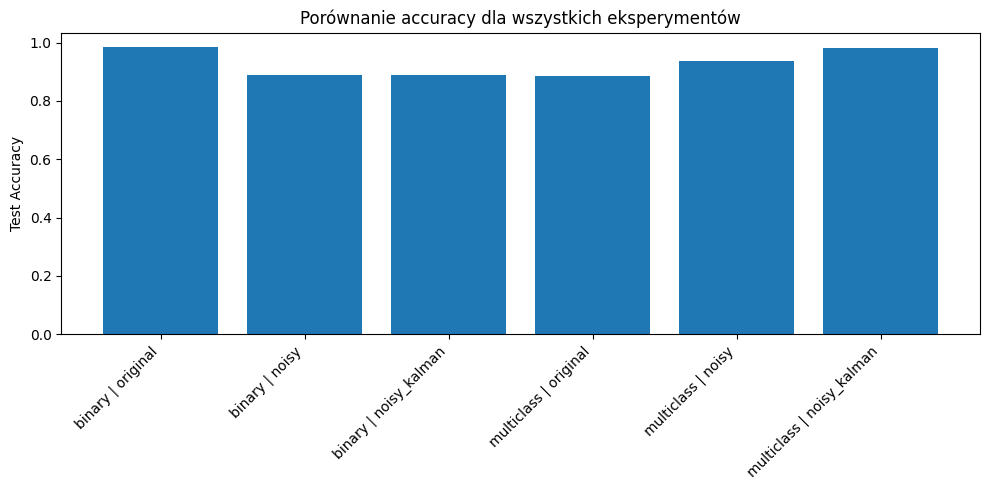

In [26]:
plt.figure(figsize=(10, 5))

labels = results_df["dataset_type"] + " | " + results_df["variant"]
values = results_df["test_acc"]

plt.bar(labels, values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Test Accuracy")
plt.title("Porównanie accuracy dla wszystkich eksperymentów")
plt.tight_layout()
plt.show()

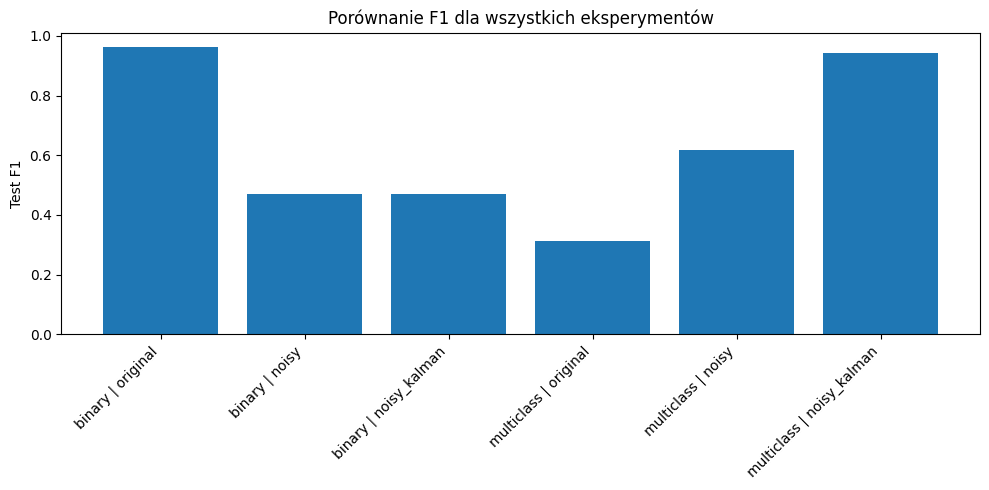

In [27]:
plt.figure(figsize=(10, 5))

labels = results_df["dataset_type"] + " | " + results_df["variant"]
values = results_df["test_f1"]

plt.bar(labels, values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Test F1")
plt.title("Porównanie F1 dla wszystkich eksperymentów")
plt.tight_layout()
plt.show()